# Digital Construcion Archive
## Gantenbein Knowledge Graph

This notebook documentes the creation of the Gantenbein Knowledge Graph. The Graph is the foundational structure to connect the RDF Data from the Droid Analysis, to the IFC-Data and further future RDF-Data (Damages, Interventions … )

In this colab notebook you will learn how to make use of the RDFlib library in python and how to create and manipulate RDF graphs with python.
Disclaimer: this document is based on an example used in the course "Knowledge Graphs - Foundations and Applications" by Prof. Dr. Harald Sack

## Setup

**[RDFlib](https://github.com/RDFLib/rdflib)** is is a Python package for working with RDF. It contains:
- parsers and serializers for RDF/XML, N3, NTriples, N-Quads, Turtle, TriX, Trig and JSON-LD
- a graph interface which can be backed by any one of a number of store implementations
- store implementations for in-memory, persistent on disk (Berkeley DB) and remote SPARQL endpoints
- a SPARQL 1.1 implementation - supporting SPARQL 1.1 Queries and Update statements
- SPARQL function extension mechanisms


We have to install the following packages:

*   **RDFlib** for working with RDF
*   **PyDotPlus** for visualization

In [1]:
%%capture
!pip3 install rdflib pydotplus SPARQLWrapper

In [2]:
#import rdflib
from rdflib import Graph, Namespace, URIRef, Literal
from rdflib.namespace import DC, RDF, FOAF, RDFS, XSD #import already in RDFlib integrated namespaces
#for visualization
import io
import pydotplus
from IPython.display import display, Image
from rdflib.tools.rdf2dot import rdf2dot
#for json
import json

In [3]:
# helper function for visualizing RDF graphs
def visualize(g):
     stream = io.StringIO()
     rdf2dot(g, stream, opts = {display})
     dg = pydotplus.graph_from_dot_data(stream.getvalue())
     png = dg.create_png()
     display(Image(png))

In [4]:
# helper function for visualizing RDF graphs in external files
def visualize_to_file(g, filename):
    stream = io.StringIO()
    rdf2dot(g, stream, opts = {display})
    dot_source = stream.getvalue()
    # Füge die Attribute direkt zur DOT-Quelle hinzu
    dot_source = 'digraph G {\nsize="1000,1000!"; dpi="300"; ratio="fill"; rankdir="LR"; splines="true"; overlap="false";\n' + dot_source[10:]
    src = Source(dot_source)
    src.format = 'png'
    src.render(filename, view=False)
    print(f"Graph wurde in {filename}.png gespeichert.")

## General Information on Gantenbein Vinery

Fabio Gramazio

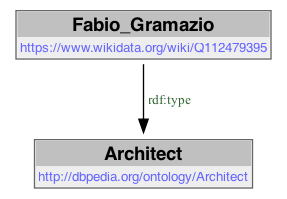

Tripel gesamt: 2


In [5]:
# ensure a cumulative graph exists across cells
if "g_all" not in globals():
    g_all = Graph()

g_part = Graph()
# create graph using turtle
turtledata = """\
PREFIX wkd: <https://www.wikidata.org/wiki/>
PREFIX dbo: <http://dbpedia.org/ontology/>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>


wkd:Q112479395  rdf:type    dbo:Architect ;
    rdfs:label  "Fabio_Gramazio"@en."""


g_part.parse(data=turtledata, format="turtle")
g_all += g_part
visualize(g_all)
print(f"Tripel gesamt: {len(g_all)}")

The building and it's designers

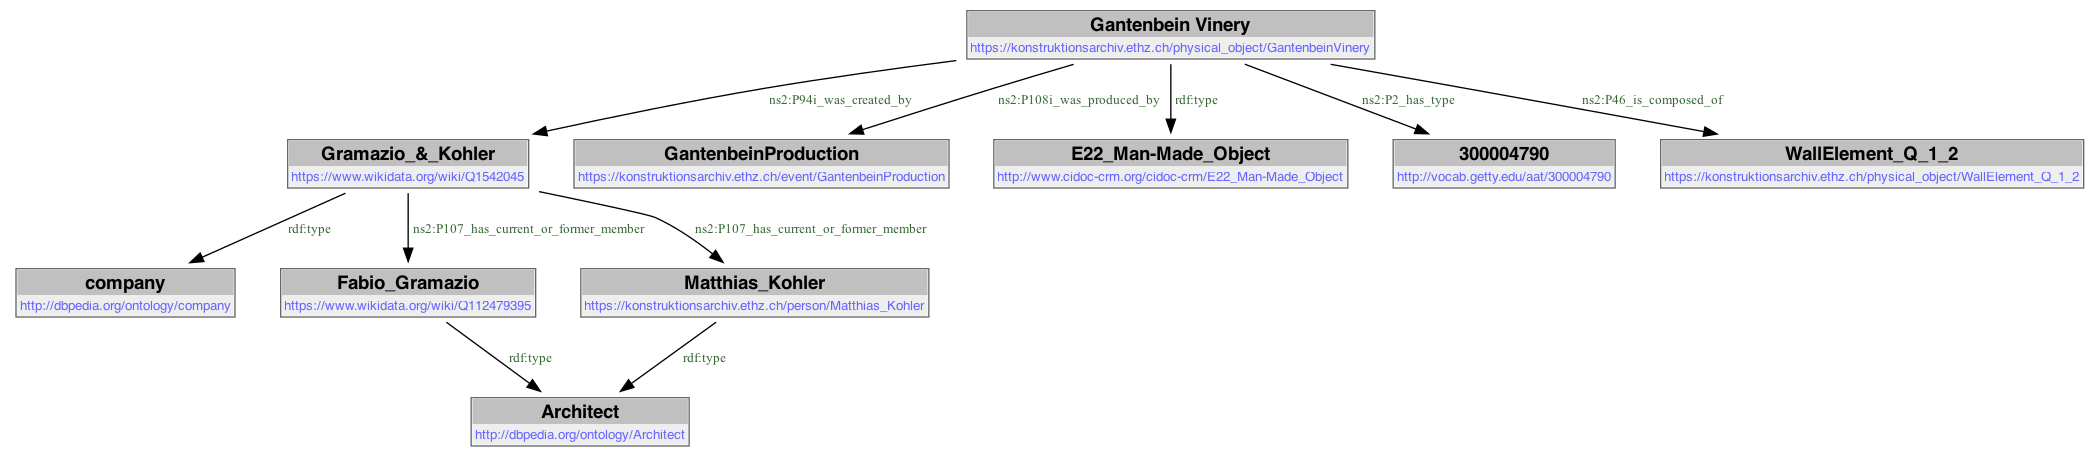

Tripel gesamt: 14


In [6]:
# ensure a cumulative graph exists across cells
if "g_all" not in globals():
    g_all = Graph()

g_part = Graph()
# create graph using turtle
turtledata = """\
PREFIX wkd: <https://www.wikidata.org/wiki/>
PREFIX dbr: <http://dbpedia.org/resource/>
PREFIX dbo: <http://dbpedia.org/ontology/>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX dca-per: <https://konstruktionsarchiv.ethz.ch/person/>
PREFIX dca-po: <https://konstruktionsarchiv.ethz.ch/physical_object/>
PREFIX dca-ev: <https://konstruktionsarchiv.ethz.ch/event/>
PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>
PREFIX crm: <http://www.cidoc-crm.org/cidoc-crm/>
PREFIX tgn: <https://vocab.getty.edu/resource/tgn/>
PREFIX aat: <http://vocab.getty.edu/aat/>

dca-per:Matthias_Kohler    rdf:type   dbo:Architect ;
    rdfs:label   "Matthias_Kohler"@en.

wkd:Q1542045   rdf:type   dbo:company ;
    rdfs:label    "Gramazio_&_Kohler"@en;
    crm:P107_has_current_or_former_member    wkd:Q112479395, dca-per:Matthias_Kohler.

dca-po:GantenbeinVinery    a    crm:E22_Man-Made_Object ;
    rdfs:label    "Gantenbein Vinery"@en ;
    crm:P2_has_type    aat:300004790;
    crm:P46_is_composed_of    dca-po:WallElement_Q_1_2 ;
    crm:P108i_was_produced_by    dca-ev:GantenbeinProduction ;	
    crm:P94i_was_created_by    wkd:Q1542045 ."""

g_part.parse(data=turtledata, format="turtle")
g_all += g_part
visualize(g_all)
print(f"Tripel gesamt: {len(g_all)}")

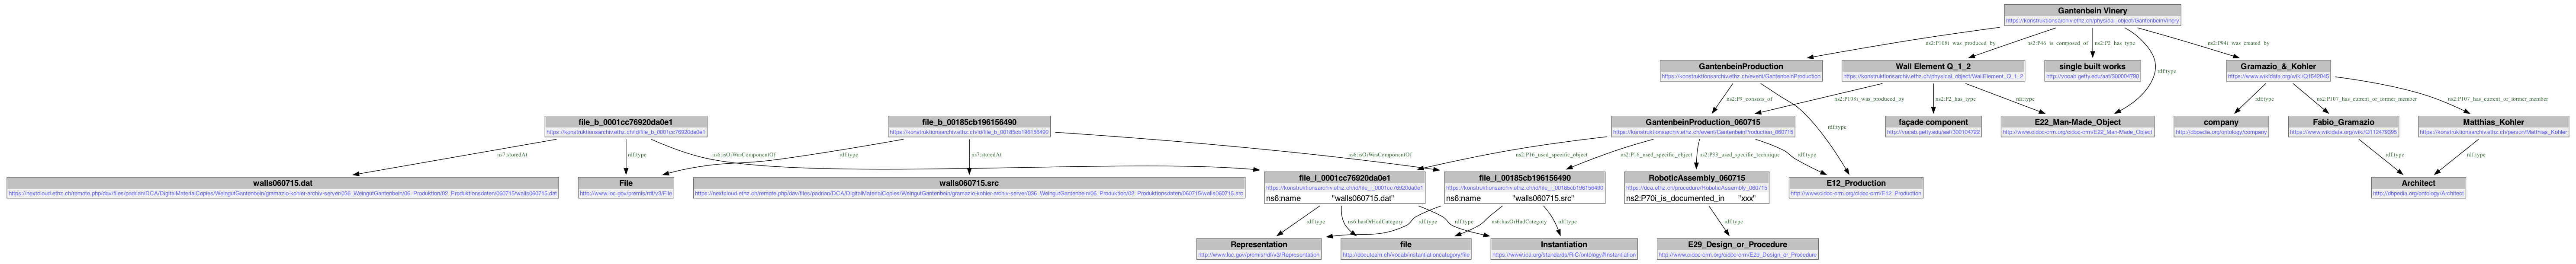

Tripel gesamt: 42


In [7]:
# ensure a cumulative graph exists across cells
if "g_all" not in globals():
    g_all = Graph()

g_part = Graph()
# create graph using turtle
turtledata = """\
PREFIX crm: <http://www.cidoc-crm.org/cidoc-crm/>
PREFIX rico: <https://www.ica.org/standards/RiC/ontology#>
PREFIX premis: <http://www.loc.gov/premis/rdf/v3/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX aat: <http://vocab.getty.edu/aat/>
PREFIX dca-id: <https://konstruktionsarchiv.ethz.ch/id/>
PREFIX dca-po: <https://konstruktionsarchiv.ethz.ch/physical_object/>
PREFIX dca-ev: <https://konstruktionsarchiv.ethz.ch/event/>
PREFIX dca-pr: <https://dca.ethz.ch/procedure/>




dca-po:WallElement_Q_1_2 a crm:E22_Man-Made_Object ;
rdfs:label "Wall Element Q_1_2"@en ;
crm:P2_has_type aat:300104722;
crm:P108i_was_produced_by dca-ev:GantenbeinProduction_060715 .

aat:300004790 rdfs:label "single built works"@en .
aat:300104722 rdfs:label "façade component"@en .

dca-ev:GantenbeinProduction a crm:E12_Production ;
crm:P9_consists_of dca-ev:GantenbeinProduction_060715 .

dca-ev:GantenbeinProduction_060715 a crm:E12_Production ;
crm:P33_used_specific_technique dca-pr:RoboticAssembly_060715 ;
crm:P16_used_specific_object dca-id:file_i_0001cc76920da0e1 ;
crm:P16_used_specific_object dca-id:file_i_00185cb196156490 .

dca-pr:RoboticAssembly_060715 a crm:E29_Design_or_Procedure ;
crm:P70i_is_documented_in "xxx".

dca-id:file_i_0001cc76920da0e1 a rico:Instantiation, premis:Representation ;
rico:name "walls060715.dat" ;
rico:hasOrHadCategory <http://docuteam.ch/vocab/instantiationcategory/file>  .

dca-id:file_i_00185cb196156490 a rico:Instantiation, premis:Representation ;
rico:name "walls060715.src" ;
rico:hasOrHadCategory <http://docuteam.ch/vocab/instantiationcategory/file> .

dca-id:file_b_0001cc76920da0e1 a premis:File ;
rico:isOrWasComponentOf  dca-id:file_i_0001cc76920da0e1;
premis:storedAt <https://nextcloud.ethz.ch/remote.php/dav/files/padrian/DCA/DigitalMaterialCopies/WeingutGantenbein/gramazio-kohler-archiv-server/036_WeingutGantenbein/06_Produktion/02_Produktionsdaten/060715/walls060715.dat> .

dca-id:file_b_00185cb196156490 a premis:File ;
rico:isOrWasComponentOf  dca-id:file_i_00185cb196156490 ;
premis:storedAt <https://nextcloud.ethz.ch/remote.php/dav/files/padrian/DCA/DigitalMaterialCopies/WeingutGantenbein/gramazio-kohler-archiv-server/036_WeingutGantenbein/06_Produktion/02_Produktionsdaten/060715/walls060715.src> ."""

g_part.parse(data=turtledata, format="turtle")
g_all += g_part
visualize(g_all)
print(f"Tripel gesamt: {len(g_all)}")